## 6.2 - **Data Cleaning and Preparation**

In [148]:
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction import DictVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

from sklearn.ensemble import RandomForestClassifier

import seaborn as sns
from matplotlib import pyplot as plt

import xgboost as xgb

In [2]:
df = pd.read_csv("/workspaces/ml-zoomcamp/data/CreditScoring.csv")
df.head()

,Status,Seniority,Home,Time,Age,Marital,Records,Job,Expenses,Income,Assets,Debt,Amount,Price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


In [3]:
df.columns = df.columns.str.lower()

In [4]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


In [5]:
status_values = {
    1: 'ok',
    2: 'default',
    0: 'unk'
}

df.status = df.status.map(status_values)


home_values = {
    1: 'rent',
    2: 'owner',
    3: 'private',
    4: 'ignore',
    5: 'parents',
    6: 'other',
    0: 'unk'
}

df.home = df.home.map(home_values)

marital_values = {
    1: 'single',
    2: 'married',
    3: 'widow',
    4: 'separated',
    5: 'divorced',
    0: 'unk'
}

df.marital = df.marital.map(marital_values)

records_values = {
    1: 'no',
    2: 'yes',
    0: 'unk'
}

df.records = df.records.map(records_values)

job_values = {
    1: 'fixed',
    2: 'partime',
    3: 'freelance',
    4: 'others',
    0: 'unk'
}

df.job = df.job.map(job_values)

In [6]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129,0,0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131,0,0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200,3000,0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182,2500,0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107,0,0,310,910


In [7]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,763317.0,1060341.0,404382.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,8703625.0,10217569.0,6344253.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3500.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,166.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,99999999.0,99999999.0,99999999.0,5000.0,11140.0


In [8]:
for c in ['income', 'assets', 'debt']:
    df[c] = df[c].replace(to_replace=99999999, value=np.nan)

In [9]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129.0,0.0,0.0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131.0,0.0,0.0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200.0,3000.0,0.0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182.0,2500.0,0.0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107.0,0.0,0.0,310,910


In [10]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4421.0,4408.0,4437.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,131.0,5403.0,343.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,86.0,11573.0,1246.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3000.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,165.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,959.0,300000.0,30000.0,5000.0,11140.0


In [11]:
df.status.value_counts()

status
ok         3200
default    1254
unk           1
Name: count, dtype: int64

In [12]:
df = df[df.status != "unk"]

In [13]:
df.status.value_counts()

status
ok         3200
default    1254
Name: count, dtype: int64

In [14]:
df = df.reset_index(drop=True)

In [15]:
n = 0.2
SEED = 11

df_full_train, df_test = train_test_split(df, test_size=n, random_state=SEED)
df_train, df_val = train_test_split(df_full_train, test_size=n/(1-n), random_state=SEED)

In [16]:
df_train.shape, df_test.shape, df_val.shape

((2672, 14), (891, 14), (891, 14))

In [17]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [18]:
y_train = (df_train.status == "default").astype(int).values
y_val = (df_val.status == "default").astype(int).values
y_test = (df_test.status == "default").astype(int).values

In [19]:
del df_train["status"]
del df_val["status"]
del df_test["status"]

In [20]:
df_train.head()

,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,10,owner,36,36,married,no,freelance,75,0.0,10000.0,0.0,1000,1400
1,6,parents,48,32,single,yes,fixed,35,85.0,0.0,0.0,1100,1330
2,1,parents,48,40,married,no,fixed,75,121.0,0.0,0.0,1320,1600
3,1,parents,48,23,single,no,partime,35,72.0,0.0,0.0,1078,1079
4,5,owner,36,46,married,no,freelance,60,100.0,4000.0,0.0,1100,1897


## 6.3 - **Decision Trees**

In [21]:
def assess_risk(client):
    if client["records"] == "yes":
        if client["job"] == "parttime":
            return "default"
        else:
            return "ok"
    else:
        if client["assets"] > 6000:
            return "ok"
        else:
            return "default"


In [22]:
xi = df_train.iloc[0].to_dict() 

In [23]:
assess_risk(xi)

'ok'

In [24]:
train_dicts = df_train.fillna(0).to_dict(orient="records")
val_dicts = df_val.fillna(0).to_dict(orient="records")
test_dicts = df_test.to_dict(orient="records")

In [25]:
dv = DictVectorizer(sparse=False)

In [26]:
X_train = dv.fit_transform(train_dicts)

In [27]:
dv.get_feature_names_out()

array(['age', 'amount', 'assets', 'debt', 'expenses', 'home=ignore',
       'home=other', 'home=owner', 'home=parents', 'home=private',
       'home=rent', 'home=unk', 'income', 'job=fixed', 'job=freelance',
       'job=others', 'job=partime', 'job=unk', 'marital=divorced',
       'marital=married', 'marital=separated', 'marital=single',
       'marital=unk', 'marital=widow', 'price', 'records=no',
       'records=yes', 'seniority', 'time'], dtype=object)

In [28]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [29]:
X_val = dv.transform(val_dicts)

In [30]:
y_pred = dt.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

0.6513465404083214

In [31]:
y_pred = dt.predict_proba(X_train)[:, 1]
roc_auc_score(y_train, y_pred)

1.0

In [32]:
# The data has been overfit. 

In [33]:
dt = DecisionTreeClassifier(max_depth=2)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [34]:
y_pred = dt.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

0.6685264343319367

In [35]:
y_pred = dt.predict_proba(X_train)[:, 1]
roc_auc_score(y_train, y_pred)

0.7054989859726213

In [36]:
from sklearn.tree import export_text

In [37]:
print(export_text(dt, feature_names=dv.get_feature_names_out()))

|--- records=yes <= 0.50
|   |--- job=partime <= 0.50
|   |   |--- class: 0
|   |--- job=partime >  0.50
|   |   |--- class: 1
|--- records=yes >  0.50
|   |--- seniority <= 6.50
|   |   |--- class: 1
|   |--- seniority >  6.50
|   |   |--- class: 0



## 6.4 - **Decision Tree Learning Algorithm**
- Finding the best split for one column
- Finding the best split for the entire dataset
- Stopping criteria
- Decision Tree Learning Algorithm

In [38]:
data = [
    [8000, "default"],
    [2000, "default"],
    [0, "default"],
    [5000, "ok"],
    [5000, "ok"],
    [4000, "ok"],
    [9000, "ok"],
    [3000, "default"]
]

df_example = pd.DataFrame(data, columns=["assets", "status"])

In [39]:
df_example.sort_values("assets")

,assets,status
2,0,default
1,2000,default
7,3000,default
5,4000,ok
4,5000,ok
3,5000,ok
0,8000,default
6,9000,ok


In [40]:
from IPython.display import display

In [41]:
# Where do we split? 
Ts = [0, 2000, 3000, 4000, 5000, 8000]

df_results = pd.DataFrame(columns=["split", "decision_left", "impurity_left", "decision_right", "impurity_right", "avg"])

for T in Ts:
    df_left = df_example[df_example.assets <= T]
    df_right = df_example[df_example.assets > T]

    decision_left = df_left.status.mode().values[0]
    decision_right = df_right.status.mode().values[0]

    total_left = len(df_left)
    total_right = len(df_right)

    incorrect_left = (df_left.status != decision_left).sum()
    incorrect_right = (df_right.status != decision_right).sum()

    impurity_left = incorrect_left / total_left
    impurity_right = incorrect_right / total_right
    avg = (incorrect_left + incorrect_right) / (total_left + total_right)

    df_results.loc[len(df_results)] = [T, decision_left, impurity_left, decision_right, impurity_right, avg]
    

    print(f"Split on {T}")
    display(df_left)
    print(df_left.status.value_counts(normalize=True))
    display(df_right)
    print(df_right.status.value_counts(normalize=True))
    
    print(f"-------------------------\n")
df_results


Split on 0


,assets,status
2,0,default


status
default    1.0
Name: proportion, dtype: float64


,assets,status
0,8000,default
1,2000,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,3000,default


status
ok         0.571429
default    0.428571
Name: proportion, dtype: float64
-------------------------

Split on 2000


,assets,status
1,2000,default
2,0,default


status
default    1.0
Name: proportion, dtype: float64


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,3000,default


status
ok         0.666667
default    0.333333
Name: proportion, dtype: float64
-------------------------

Split on 3000


,assets,status
1,2000,default
2,0,default
7,3000,default


status
default    1.0
Name: proportion, dtype: float64


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok


status
ok         0.8
default    0.2
Name: proportion, dtype: float64
-------------------------

Split on 4000


,assets,status
1,2000,default
2,0,default
5,4000,ok
7,3000,default


status
default    0.75
ok         0.25
Name: proportion, dtype: float64


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
6,9000,ok


status
ok         0.75
default    0.25
Name: proportion, dtype: float64
-------------------------

Split on 5000


,assets,status
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok
7,3000,default


status
default    0.5
ok         0.5
Name: proportion, dtype: float64


,assets,status
0,8000,default
6,9000,ok


status
default    0.5
ok         0.5
Name: proportion, dtype: float64
-------------------------

Split on 8000


,assets,status
0,8000,default
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok
7,3000,default


status
default    0.571429
ok         0.428571
Name: proportion, dtype: float64


,assets,status
6,9000,ok


status
ok    1.0
Name: proportion, dtype: float64
-------------------------



,split,decision_left,impurity_left,decision_right,impurity_right,avg
0,0,default,0.000000,ok,0.428571,0.375
1,2000,default,0.000000,ok,0.333333,0.250
2,3000,default,0.000000,ok,0.200000,0.125
3,4000,default,0.250000,ok,0.250000,0.250
4,5000,default,0.500000,default,0.500000,0.500
5,8000,default,0.428571,ok,0.000000,0.375


In [42]:
data = [
    [8000, 3000, "default"],
    [2000, 1000, "default"],
    [0, 1000, "default"],
    [5000, 1000, "ok"],
    [5000, 1000, "ok"],
    [4000, 1000, "ok"],
    [9000, 500, "ok"],
    [3000, 2000, "default"]
]

df_example = pd.DataFrame(data, columns=["assets", "debt", "status"])
df_example

,assets,debt,status
0,8000,3000,default
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok
7,3000,2000,default


In [43]:
df_example.sort_values("debt")

,assets,debt,status
6,9000,500,ok
1,2000,1000,default
3,5000,1000,ok
2,0,1000,default
5,4000,1000,ok
4,5000,1000,ok
7,3000,2000,default
0,8000,3000,default


In [44]:
thresholds = {
    "assets"   : [0, 2000, 3000, 4000, 5000, 8000],
    "debt": [500, 1000, 2000]
}

Stopping Criteria:
- Group already pure
- Tree reached depth limit
- Group too small to split

## 6.5 - **Decision Trees Parameter Tuning**
- selecting `max_depth`
- selection `min_samples_leaf`

In [45]:
# We are interested in max_depth and min_samples_leaf, 
DecisionTreeClassifier?

Init signature:
DecisionTreeClassifier(
    *,
    criterion='gini',
    splitter='best',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features=None,
    random_state=None,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    class_weight=None,
    ccp_alpha=0.0,
    monotonic_cst=None,
)
Docstring:     
A decision tree classifier.

Read more in the :ref:`User Guide <tree>`.

Parameters
----------
criterion : {"gini", "entropy", "log_loss"}, default="gini"
    The function to measure the quality of a split. Supported criteria are
    "gini" for the Gini impurity and "log_loss" and "entropy" both for the
    Shannon information gain, see :ref:`tree_mathematical_formulation`.

splitter : {"best", "random"}, default="best"
    The strategy used to choose the split at each node. Supported
    strategies are "best" to choose the best split and "random" to choose
    the best random split.

max_depth : int, default=None

In [46]:
depths = [1,2,3,4,5,6,10,15,20,None]

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d)

    dt.fit(X_train, y_train)

    y_pred_train = dt.predict_proba(X_train)[:, 1]
    y_pred = dt.predict_proba(X_val)[:, 1]

    auc_train = roc_auc_score(y_train, y_pred_train)
    auc = roc_auc_score(y_val, y_pred)


    print(f"%4s -> %.3f,  %.3f" %(d,auc_train, auc))

   1 -> 0.628,  0.606
   2 -> 0.705,  0.669
   3 -> 0.776,  0.739
   4 -> 0.816,  0.761
   5 -> 0.843,  0.767
   6 -> 0.874,  0.760
  10 -> 0.964,  0.688
  15 -> 0.998,  0.654
  20 -> 1.000,  0.653
None -> 1.000,  0.657


In [47]:
scores = []

depths = [4,5,6,7,8,9,10,15,20,None]
leaf_samples = [1,2,5,10,15,20,100,200,500]

for d in depths:
    for s in leaf_samples:
        dt = DecisionTreeClassifier(max_depth=d, min_samples_leaf=s)

        dt.fit(X_train, y_train)

        y_pred_train = dt.predict_proba(X_train)[:, 1]
        y_pred = dt.predict_proba(X_val)[:, 1]

        auc_train = roc_auc_score(y_train, y_pred_train)
        auc = roc_auc_score(y_val, y_pred)

        scores.append([d, s, auc])

        #print(f"(%1s, %3s) -> %.3f,  %.3f" %(d, s, auc_train, auc))

df_scores = pd.DataFrame(data=scores, columns=["max_depth", "min_samples_leaf", "auc"])
df_scores.sort_values(by="auc", ascending=False).head()

,max_depth,min_samples_leaf,auc
58,10.0,15,0.788556
76,20.0,15,0.787375
67,15.0,15,0.787142
49,9.0,15,0.786633
50,9.0,20,0.786203


In [48]:
df_scores_pivot = df_scores.pivot(index="min_samples_leaf", columns="max_depth", values=["auc"])
df_scores_pivot.round(3)

auc                                                   \
max_depth           NaN   4.0    5.0    6.0    7.0    8.0    9.0    10.0   
min_samples_leaf                                                           
1                 0.647  0.761  0.767  0.761  0.738  0.741  0.710  0.695   
2                 0.690  0.761  0.766  0.767  0.759  0.750  0.719  0.721   
5                 0.713  0.761  0.768  0.762  0.756  0.747  0.744  0.725   
10                0.758  0.761  0.762  0.778  0.765  0.764  0.765  0.765   
15                0.786  0.764  0.773  0.786  0.779  0.780  0.787  0.789   
20                0.784  0.761  0.774  0.774  0.779  0.779  0.786  0.785   
100               0.779  0.756  0.763  0.776  0.780  0.779  0.780  0.779   
200               0.768  0.747  0.759  0.768  0.768  0.768  0.768  0.768   
500               0.680  0.680  0.680  0.680  0.680  0.680  0.680  0.680   

                                
max_depth          15.0   20.0  
min_samples_leaf                
1                 0.664  0.655  
2                 0.694  0.695  
5                 0.719  0.720  
10                0.762  0.763  
15                0.787  0.787  
20                0.784  0.782  
100               0.780  0.780  
200               0.768  0.768  
500               0.680  0.680

<Axes: xlabel='None-max_depth', ylabel='min_samples_leaf'>

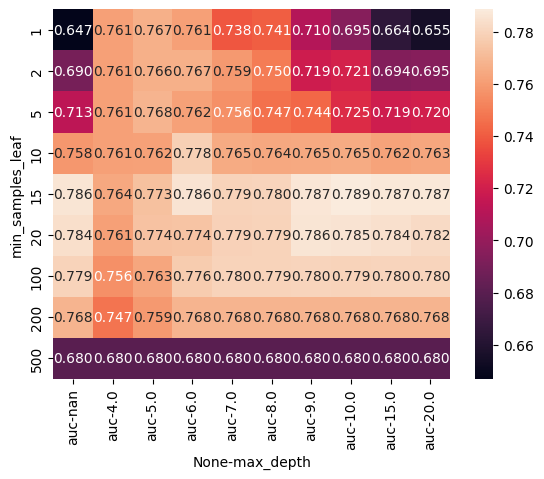

In [49]:
sns.heatmap(df_scores_pivot, annot=True, fmt=".3f")

In [50]:
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=15)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,15
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## 6.6 - **Ensembles and Random Forests**
- Board of experts
- Ensembling Models
- Random Forest - ensembling decision trees
- Tuning Random forest

In [51]:
RandomForestClassifier?

Init signature:
RandomForestClassifier(
    n_estimators=100,
    *,
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features='sqrt',
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    bootstrap=True,
    oob_score=False,
    n_jobs=None,
    random_state=None,
    verbose=0,
    warm_start=False,
    class_weight=None,
    ccp_alpha=0.0,
    max_samples=None,
    monotonic_cst=None,
)
Docstring:     
A random forest classifier.

A random forest is a meta estimator that fits a number of decision tree
classifiers on various sub-samples of the dataset and uses averaging to
improve the predictive accuracy and control over-fitting.
Trees in the forest use the best split strategy, i.e. equivalent to passing
`splitter="best"` to the underlying :class:`~sklearn.tree.DecisionTreeClassifier`.
The sub-sample size is controlled with the `max_samples` parameter if
`bootstrap=True` (default), otherwise the

In [52]:
rf = RandomForestClassifier(n_estimators=10, random_state=SEED)
rf.fit(X_train, y_train)

,n_estimators,10
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [53]:
y_pred = rf.predict_proba(X_val)[:, 1]

In [54]:
roc_auc_score(y_val, y_pred)

0.775468625124119

In [55]:
rf.predict_proba(X_val[[0]])

array([[0.9, 0.1]])

In [56]:
n_trees = [i for i in range(10, 401, 10)]

scores = []

for n in n_trees:
    rf = RandomForestClassifier(n_estimators=n, random_state=SEED)
    rf.fit(X_train, y_train)

    y_pred = rf.predict_proba(X_val)[:, 1]

    auc = roc_auc_score(y_val, y_pred)

    scores.append([n, auc])

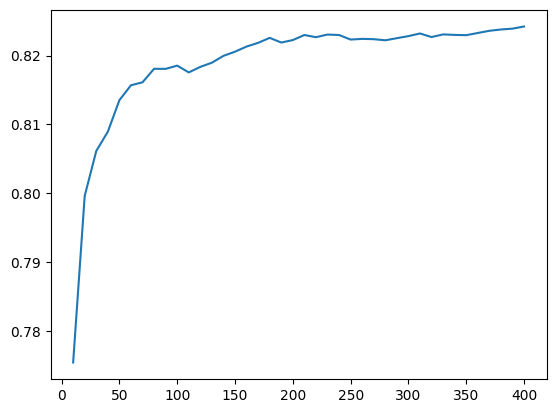

In [57]:
df_scores = pd.DataFrame(data=scores, columns=["n_trees", "auc"])
plt.plot(df_scores.n_trees, df_scores.auc)

In [58]:
n_trees = [i for i in range(20, 101, 5)]

depths = [5, 10, 15]

scores = []

for d in depths:
    for n in n_trees:
        rf = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=SEED)
        rf.fit(X_train, y_train)

        y_pred = rf.predict_proba(X_val)[:, 1]

        auc = roc_auc_score(y_val, y_pred)

        scores.append([n, d, auc])

Text(0, 0.5, 'AUC Score')

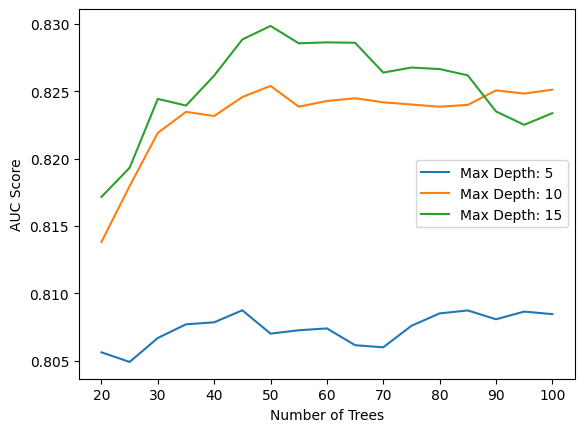

In [59]:
df_scores = pd.DataFrame(data=scores, columns=["n_trees", "max_depth", "auc"])
df_scores.head()

for d in depths:
    df_subset = df_scores[df_scores.max_depth==d]
    plt.plot(df_subset.n_trees, df_subset.auc, label=f"Max Depth: {d}")

plt.legend()
plt.xlabel("Number of Trees")
plt.ylabel("AUC Score")

In [60]:
max_depth = 10
min_samples_leaf = [1, 3, 5, 10, 50]
scores = []

for s in min_samples_leaf:
    for n in n_trees:
        rf = RandomForestClassifier(n_estimators=n, max_depth=max_depth, min_samples_leaf=s, random_state=SEED)
        rf.fit(X_train, y_train)

        y_pred = rf.predict_proba(X_val)[:, 1]

        auc = roc_auc_score(y_val, y_pred)

        scores.append([s, n, auc])

Text(0, 0.5, 'AUC Score')

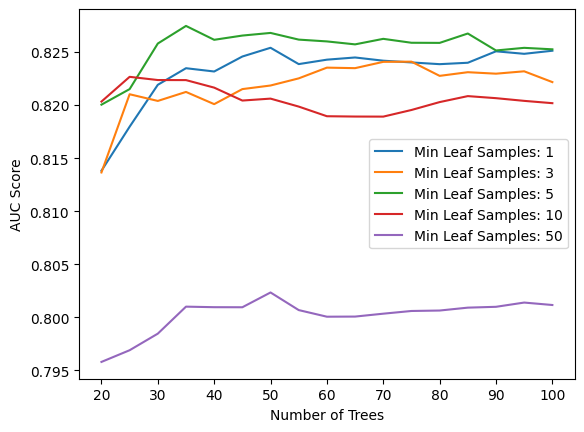

In [61]:
columns = ["min_samples_leaf", "n_trees", "auc"]

df_scores = pd.DataFrame(data=scores, columns=columns)
df_scores.head()

colors = ["black", "blue", "orange", "red", "grey"]

for s in min_samples_leaf:
    df_subset = df_scores[df_scores.min_samples_leaf==s]
    plt.plot(df_subset.n_trees, df_subset.auc, label=f"Min Leaf Samples: {s}")

plt.legend()
plt.xlabel("Number of Trees")
plt.ylabel("AUC Score")

In [62]:
min_samples_leaf = 3
n_estimators = 100
max_depth = 10

rf = RandomForestClassifier(n_estimators=100, max_depth=max_depth, min_samples_leaf=min_samples_leaf, random_state=SEED)
rf.fit(X_train, y_train)

y_pred = rf.predict_proba(X_val)[:, 1]

## 6.7 - **Gradient Boosting and XGBoost**
- Grradient Boosting vs Random Forest
- Installing XGBoost
- Training the first model
- Performance Monitoring
- Pasing XGBoost's monitoring output

In [63]:
features = list(dv.get_feature_names_out())


dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)

In [64]:
xgb_params = {
    "eta"               : 0.3,
    "max_depth"         : 6,
    "min_child_weight"  : 1,

    "objective"         : "binary:logistic",
    "nthread"           : 2,
    "seed"              : 1,
    "verbosity"         : 1, 
}

model = xgb.train(xgb_params, dtrain, num_boost_round=10)

In [65]:
y_pred = model.predict(dval)
roc_auc_score(y_val, y_pred)

0.8118506454190986

In [66]:
watchlist = [(dtrain, "train"), (dval, "val")]

In [67]:
%%capture output

xgb_params = {
    "eta"               : 0.3,
    "max_depth"         : 6,
    "min_child_weight"  : 1,

    "objective"         : "binary:logistic",
    "eval_metric"       : "auc",
    "nthread"           : 2,
    "seed"              : 1,
    "verbosity"         : 1, 
}

model = xgb.train(xgb_params, dtrain, num_boost_round=201, evals=watchlist, verbose_eval=5)

In [68]:
s = output.stdout


In [69]:
def parse_xgb_output(output:str):
    lines = output.split("\n")
    results = []

    for line in lines:
        try:
            num_iter, train_auc, val_auc = line.split("\t")
            num_iter = num_iter.strip("[]")
            train_auc = float(train_auc.split(":")[1])
            val_auc = float(val_auc.split(":")[1])
            results.append([num_iter, train_auc, val_auc])
        except: 
            pass
    
    columns = ["num_iter", "train_auc", "val_auc"]
    df_results = pd.DataFrame(data=results, columns=columns)
    return df_results

In [70]:
df_score = parse_xgb_output(s)
df_score.head()

,num_iter,train_auc,val_auc
0,0,0.86653,0.77999
1,5,0.92969,0.80822
2,10,0.95512,0.81115
3,15,0.96767,0.81993
4,20,0.97648,0.81877


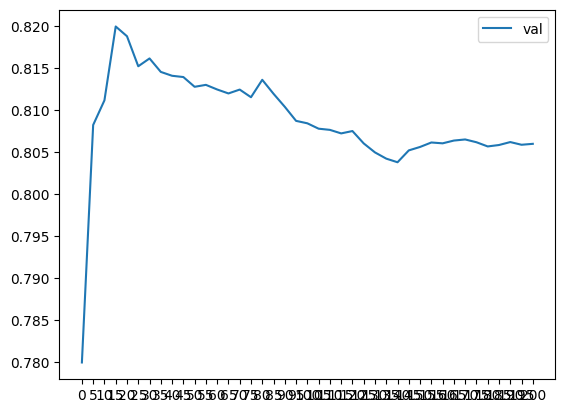

In [ ]:
#plt.plot(df_score.num_iter, df_score.train_auc, label="train")
plt.plot(df_score.num_iter, df_score.val_auc, label="val")

plt.legend()

## 6.8 - **XGBoost Parameter Tuning**
- eta
- max_depth
- min_child_weight

In [72]:
# eta -     "learning rate", how much weight a model has when correcting the previous model. What 
#           fraction of the errors to correct.

scores = {}

In [73]:
%%capture output



xgb_params = {
    "eta"               : 0.1,
    "max_depth"         : 6,
    "min_child_weight"  : 1,

    "objective"         : "binary:logistic",
    "eval_metric"       : "auc",
    "nthread"           : 2,
    "seed"              : 1,
    "verbosity"         : 0, 
}

model = xgb.train(xgb_params, dtrain, num_boost_round=200, evals=watchlist, verbose_eval=5)



In [74]:
key = "eta=%s" % (xgb_params["eta"])
scores[key] = parse_xgb_output(output.stdout)
scores.keys()

dict_keys(['eta=0.1'])

Text(0, 0.5, 'AUC Score')

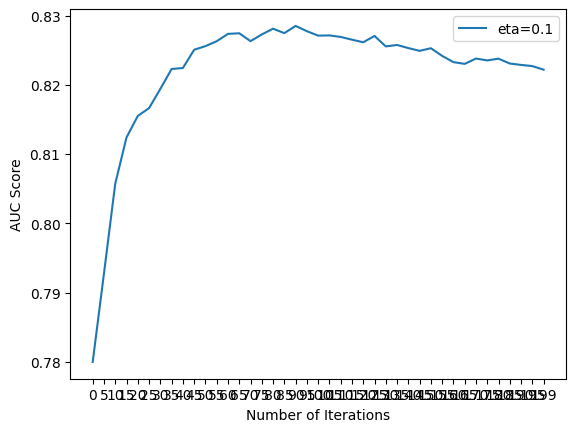

In [75]:


for key, df_scores in scores.items():
    plt.plot(df_scores.num_iter, df_scores.val_auc, label=key)

plt.legend()
plt.xlabel("Number of Iterations")
plt.ylabel("AUC Score")

In [94]:
best_eta = 0.1
scores = {}
# Tuning max_depth

In [113]:
%%capture output



xgb_params = {
    "eta"               : best_eta,
    "max_depth"         : 4,
    "min_child_weight"  : 1,

    "objective"         : "binary:logistic",
    "eval_metric"       : "auc",
    "nthread"           : 2,
    "seed"              : 1,
    "verbosity"         : 0, 
}

model = xgb.train(xgb_params, dtrain, num_boost_round=200, evals=watchlist, verbose_eval=5)




In [114]:
key = f"max_depth={xgb_params['max_depth']}"
scores[key] = parse_xgb_output(output.stdout)
scores.keys()

dict_keys(['max_depth=1', 'max_depth=2', 'max_depth=5', 'max_depth=10', 'max_depth=20', 'max_depth=3', 'max_depth=4'])

In [80]:
del scores["max_depth=10"]

KeyError: 'max_depth=10'

([<matplotlib.axis.XTick at 0x77f0e69ad7c0>,
 [Text(0, 0, '0'),
  Text(5, 0, '25'),
  Text(10, 0, '50'),
  Text(15, 0, '75'),
  Text(20, 0, '100'),
  Text(25, 0, '125'),
  Text(30, 0, '150'),
  Text(35, 0, '175'),
  Text(40, 0, '199')])

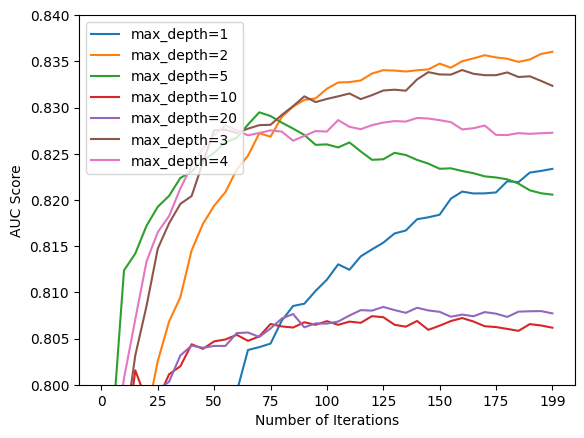

In [115]:
for key, df_scores in scores.items():
    plt.plot(df_scores.num_iter, df_scores.val_auc, label=key)

plt.legend()
plt.xlabel("Number of Iterations")
plt.ylabel("AUC Score")
plt.ylim(0.8, 0.84)
plt.xticks(range(0, 42, 5))

In [116]:
best_depth = 2
scores = {}

In [128]:
%%capture output

xgb_params = {
    "eta"               : best_eta,
    "max_depth"         : best_depth,
    "min_child_weight"  : 100,

    "objective"         : "binary:logistic",
    "eval_metric"       : "auc",
    "nthread"           : 2,
    "seed"              : 1,
    "verbosity"         : 0, 
}

model = xgb.train(xgb_params, dtrain, num_boost_round=200, evals=watchlist, verbose_eval=1)


In [129]:
key = f"min_child_weight={xgb_params['min_child_weight']}"
scores[key] = parse_xgb_output(output.stdout)
scores.keys()

dict_keys(['min_child_weight=30', 'min_child_weight=10', 'min_child_weight=20', 'min_child_weight=40', 'min_child_weight=50', 'min_child_weight=100'])

([<matplotlib.axis.XTick at 0x77f0e66a32f0>,
 [Text(0, 0, '0'),
  Text(25, 0, '25'),
  Text(50, 0, '50'),
  Text(75, 0, '75'),
  Text(100, 0, '100'),
  Text(125, 0, '125'),
  Text(150, 0, '150'),
  Text(175, 0, '175'),
  Text(200, 0, '')])

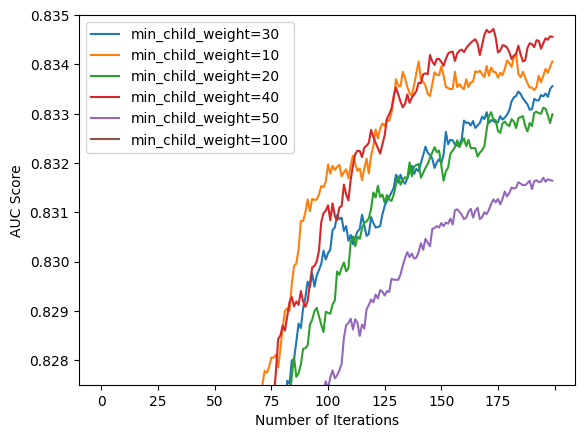

In [133]:
for key, df_scores in scores.items():
    plt.plot(df_scores.num_iter, df_scores.val_auc, label=key)

plt.legend()
plt.xlabel("Number of Iterations")
plt.ylabel("AUC Score")
plt.ylim(0.8275, 0.835)
plt.xticks(range(0, 200 + 1, 25))

In [134]:
best_min_child_weight = 40

xgb_params = {
    "eta"               : best_eta,
    "max_depth"         : best_depth,
    "min_child_weight"  : best_min_child_weight,

    "objective"         : "binary:logistic",
    "eval_metric"       : "auc",
    "nthread"           : 2,
    "seed"              : 1,
    "verbosity"         : 0, 
}

model = xgb.train(xgb_params, dtrain, num_boost_round=175)

## 6.9 - **Selecting the Best Model**
- Choosing between XGBoost, Random Forest and Decision Tree
- Training the final model
- Saving the model

In [135]:
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=15)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,15
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [136]:
#min_samples_leaf = 3
#n_estimators = 100
#max_depth = 10

rf = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=3, random_state=SEED)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [137]:
best_min_child_weight = 40

xgb_params = {
    "eta"               : best_eta,
    "max_depth"         : best_depth,
    "min_child_weight"  : best_min_child_weight,

    "objective"         : "binary:logistic",
    "eval_metric"       : "auc",
    "nthread"           : 2,
    "seed"              : 1,
    "verbosity"         : 0, 
}

model = xgb.train(xgb_params, dtrain, num_boost_round=175)

In [ ]:
y_pred_dt = dt.predict_proba(X_val)[:, 1]

roc_auc_score(y_val, y_pred_dt)

0.7853194400716863

In [145]:
y_pred_rf = rf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred_rf)

0.8221616090673511

In [149]:
y_pred_xg = model.predict(dval)

roc_auc_score(y_val, y_pred_xg)

0.8345371872805213

In [152]:
df_full_train = df_full_train.reset_index(drop=True)

In [154]:
y_full_train = (df_full_train.status == "default").astype(int)

In [155]:
y_full_train

0       0
1       1
2       0
3       0
4       0
       ..
3558    1
3559    0
3560    0
3561    0
3562    1
Name: status, Length: 3563, dtype: int64

In [156]:
del df_full_train["status"]

In [159]:
dicts_full_train = df_full_train.to_dict(orient="records")
dicts_test = df_test.to_dict(orient="records")


In [160]:
dv = DictVectorizer(sparse=False)
X_full_train = dv.fit_transform(dicts_full_train)
X_test = dv.transform(dicts_test)

In [163]:
dfulltrain = xgb.DMatrix(X_full_train, label=y_full_train, feature_names=list(dv.get_feature_names_out()))

In [164]:
dtest = xgb.DMatrix(X_test, feature_names=list(dv.get_feature_names_out()))

In [165]:
xgb_params = {
    "eta"               : best_eta,
    "max_depth"         : best_depth,
    "min_child_weight"  : best_min_child_weight,

    "objective"         : "binary:logistic",
    "eval_metric"       : "auc",
    "nthread"           : 2,
    "seed"              : 1,
    "verbosity"         : 0, 
}

In [166]:
model = xgb.train(xgb_params, dfulltrain, num_boost_round=175)

In [169]:
y_pred = model.predict(dtest)

roc_auc_score(y_test, y_pred)

0.8342700747764038

In [ ]:
# XGBoost is generally best for tabular datasets